# Variational Autoencoder for the MINIST Dataset

In [ ]:
# Deep learning and neural networks
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# Loading and transforming the MINIST dataset
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import save_image

from vae import VAE

# General-purpose libraries
import numpy as np
import math
import cv2
import matplotlib.pyplot as plt

The set_seed function is used to ensure reproducibility of results by setting the random seed for various libraries. This is crucial in machine learning experiments to obtain consistent results across different runs.

In [8]:
SEED = 42
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
set_seed(SEED)

The viridis colormap is used for better visualization of the generated images. You can change it to 'gray' if you prefer grayscale images.

In [9]:
CMAP = 'viridis'

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


### Downloading the dataset

The MINST dataset is a collection of handwritten digits that is commonly used for training various image processing systems. It contains 60,000 training images and 10,000 testing images. Each image is a 28x28 grayscale image.

In this part, we will download the dataset using the `torchvision` library.

In [11]:
trainset =  torchvision.datasets.MNIST(root='./data', train=True,   download=True, transform=transforms.ToTensor())
testset =   torchvision.datasets.MNIST(root='./data', train=False,  download=True, transform=transforms.ToTensor())

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.96MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 129kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.2MB/s]


### Training and Validation Sets

For the training set, only the first 1000 samples of each class (0-9) are selected to create a balanced validation set with 1000 samples per class. This results in a total of 10000 samples for the validation set.

For the validation set, only the first 1000 samples are selected.

In [12]:
# Training set transformed into numpy arrays for easier manipulation
x_train = trainset.data.numpy()
y_train = trainset.targets.numpy()

# Creating a balanced validation set with 1000 samples per class

idx = []
for j in range(10):
    # It selects the first 1000 indices of the class j from the training set
    # to create a balanced validation set with 1000 samples per class.
    indices_clase = np.where(y_train == j)[0][:1000]
    idx.extend(indices_clase)

x_train_pre  = x_train[idx]
y_train      = y_train[idx]

In [13]:
# Creating the validation set with 1000 samples

x_val_pre    = testset.data[:1000].numpy()
y_val        = testset.targets[:1000].numpy()

### Examples of the dataset

Some examples of the dataset are shown below. Each image is a 28x28 grayscale image representing a handwritten digit.

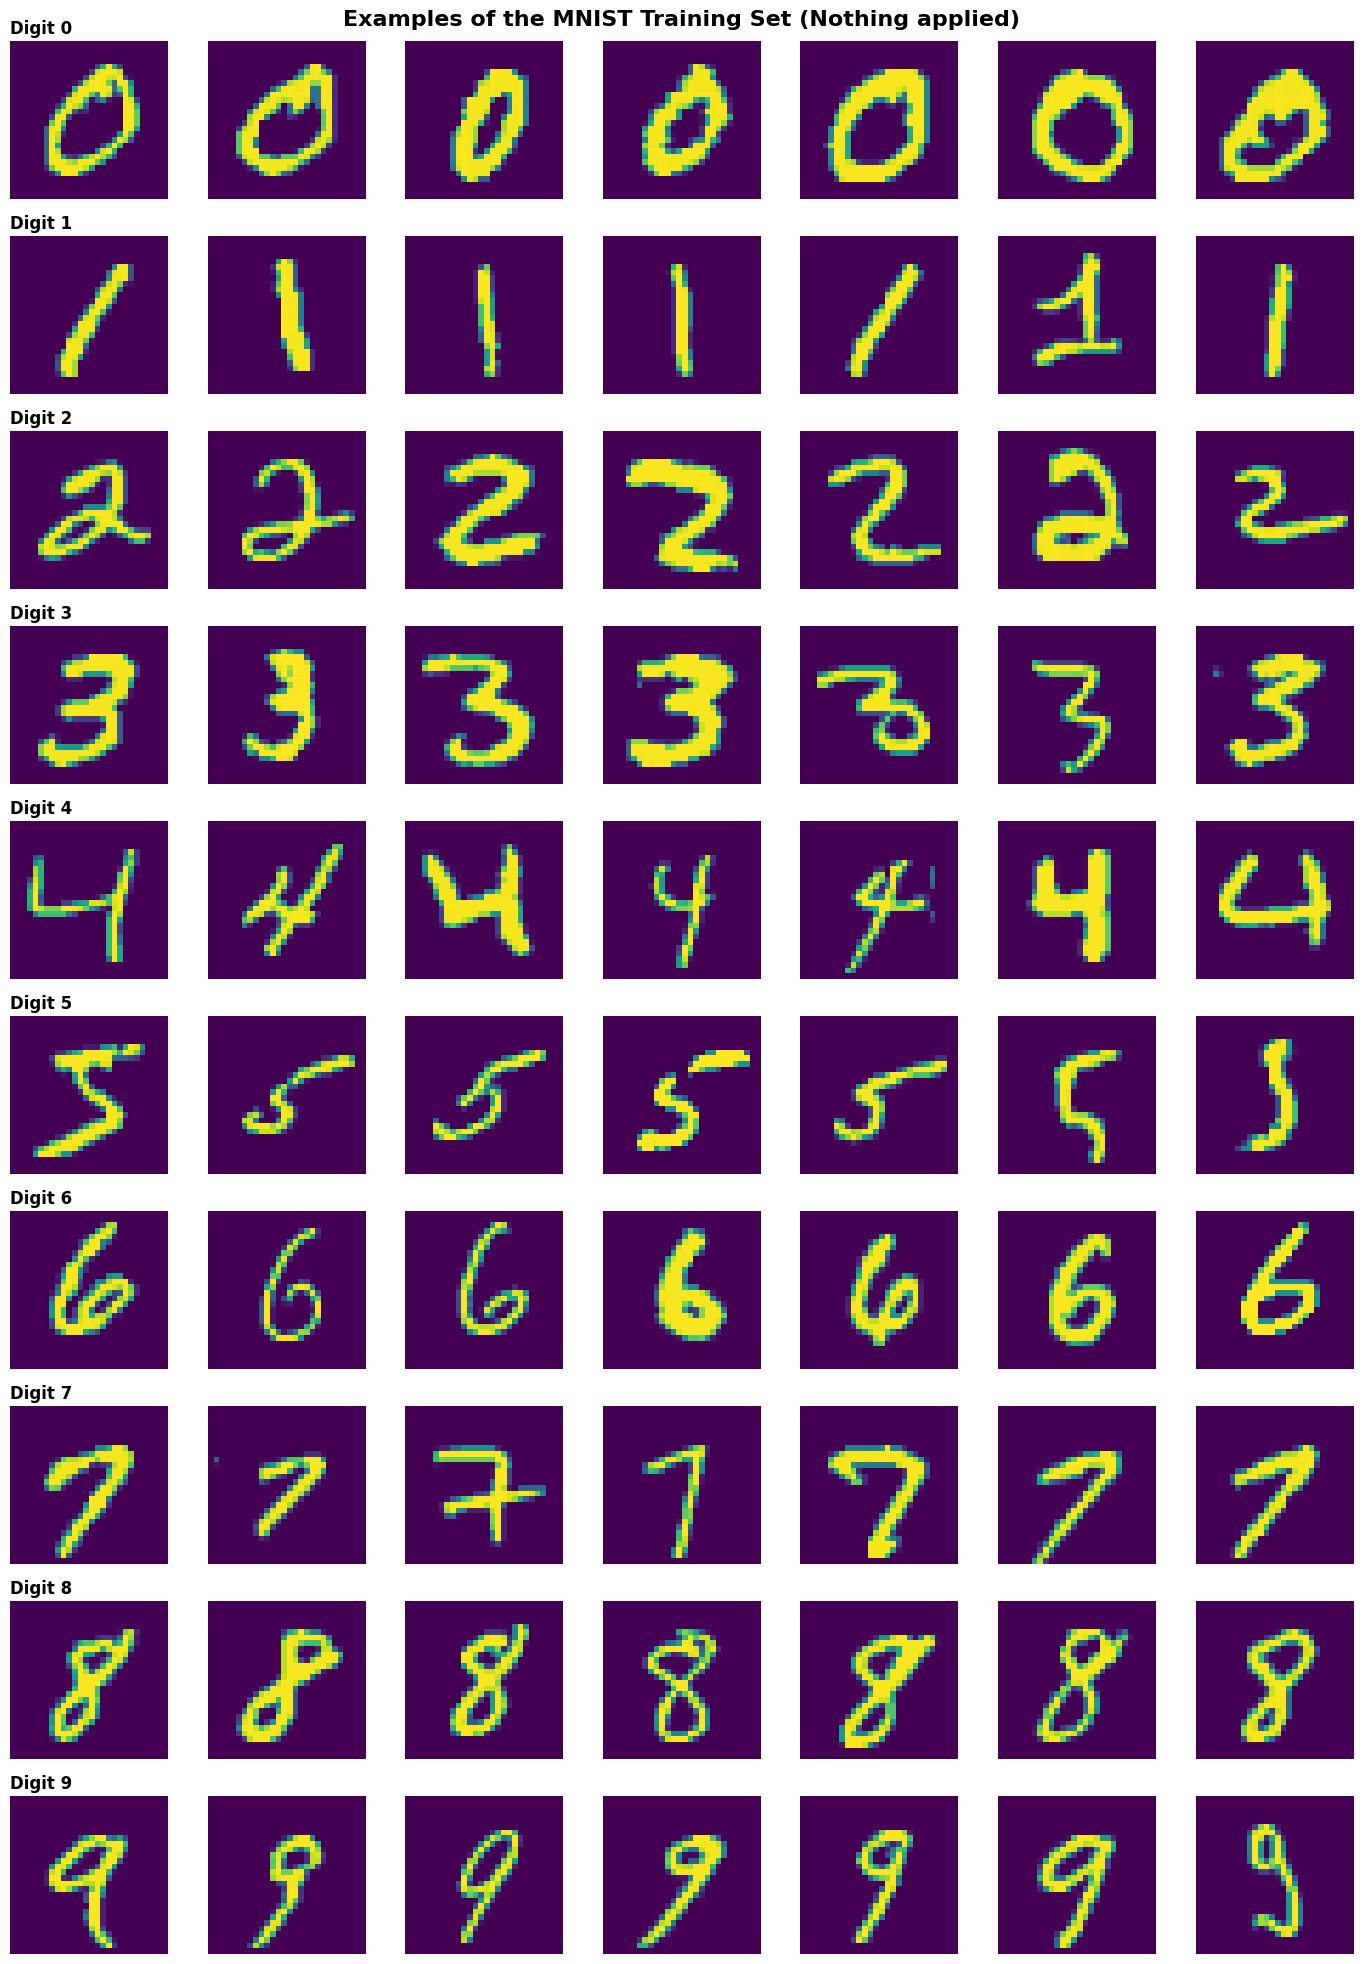

In [14]:
def show_examples(x_data, y_data, num_classes=10, num_photos=5, title=None):
    """
    Displays a grid of images from the dataset.

    Parameters:
    - x_data: The input data (images) to display.
    - y_data: The corresponding labels for the images.
    - num_classes: Number of classes to display (default is 10 for MNIST).
    - num_photos: Number of photos per class to display (default is 5).
    - title: Title for the entire figure (default is None).
    """
    
    fig, axes = plt.subplots(num_classes, num_photos, figsize=(num_photos * 2, num_classes * 2))
    
    if title:
        fig.suptitle(title, fontsize=16, fontweight='bold')
    
    for digit in range(num_classes):
        # Get indices of all images belonging to the current digit
        digit_indices = np.where(y_data == digit)[0]
        
        for photo_idx in range(num_photos):
            # Select the current index for the digit
            current_idx = digit_indices[photo_idx]
            
            # Select the appropriate axis for the current digit and photo index
            ax = axes[digit, photo_idx]
            
            ax.imshow(x_data[current_idx], cmap=CMAP)
            ax.axis('off')  # No need to see the axis for each image
            
            if photo_idx == 0:
                ax.set_title(f'Digit {digit}', loc='left', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


show_examples(x_train_pre, y_train, num_classes=10, num_photos=7, title="Examples of the MNIST Training Set (Nothing applied)")

### Image Redimensioning

Images are redimensioned, in case of using a smaller size, to reduce the number of parameters in the model and speed up training.

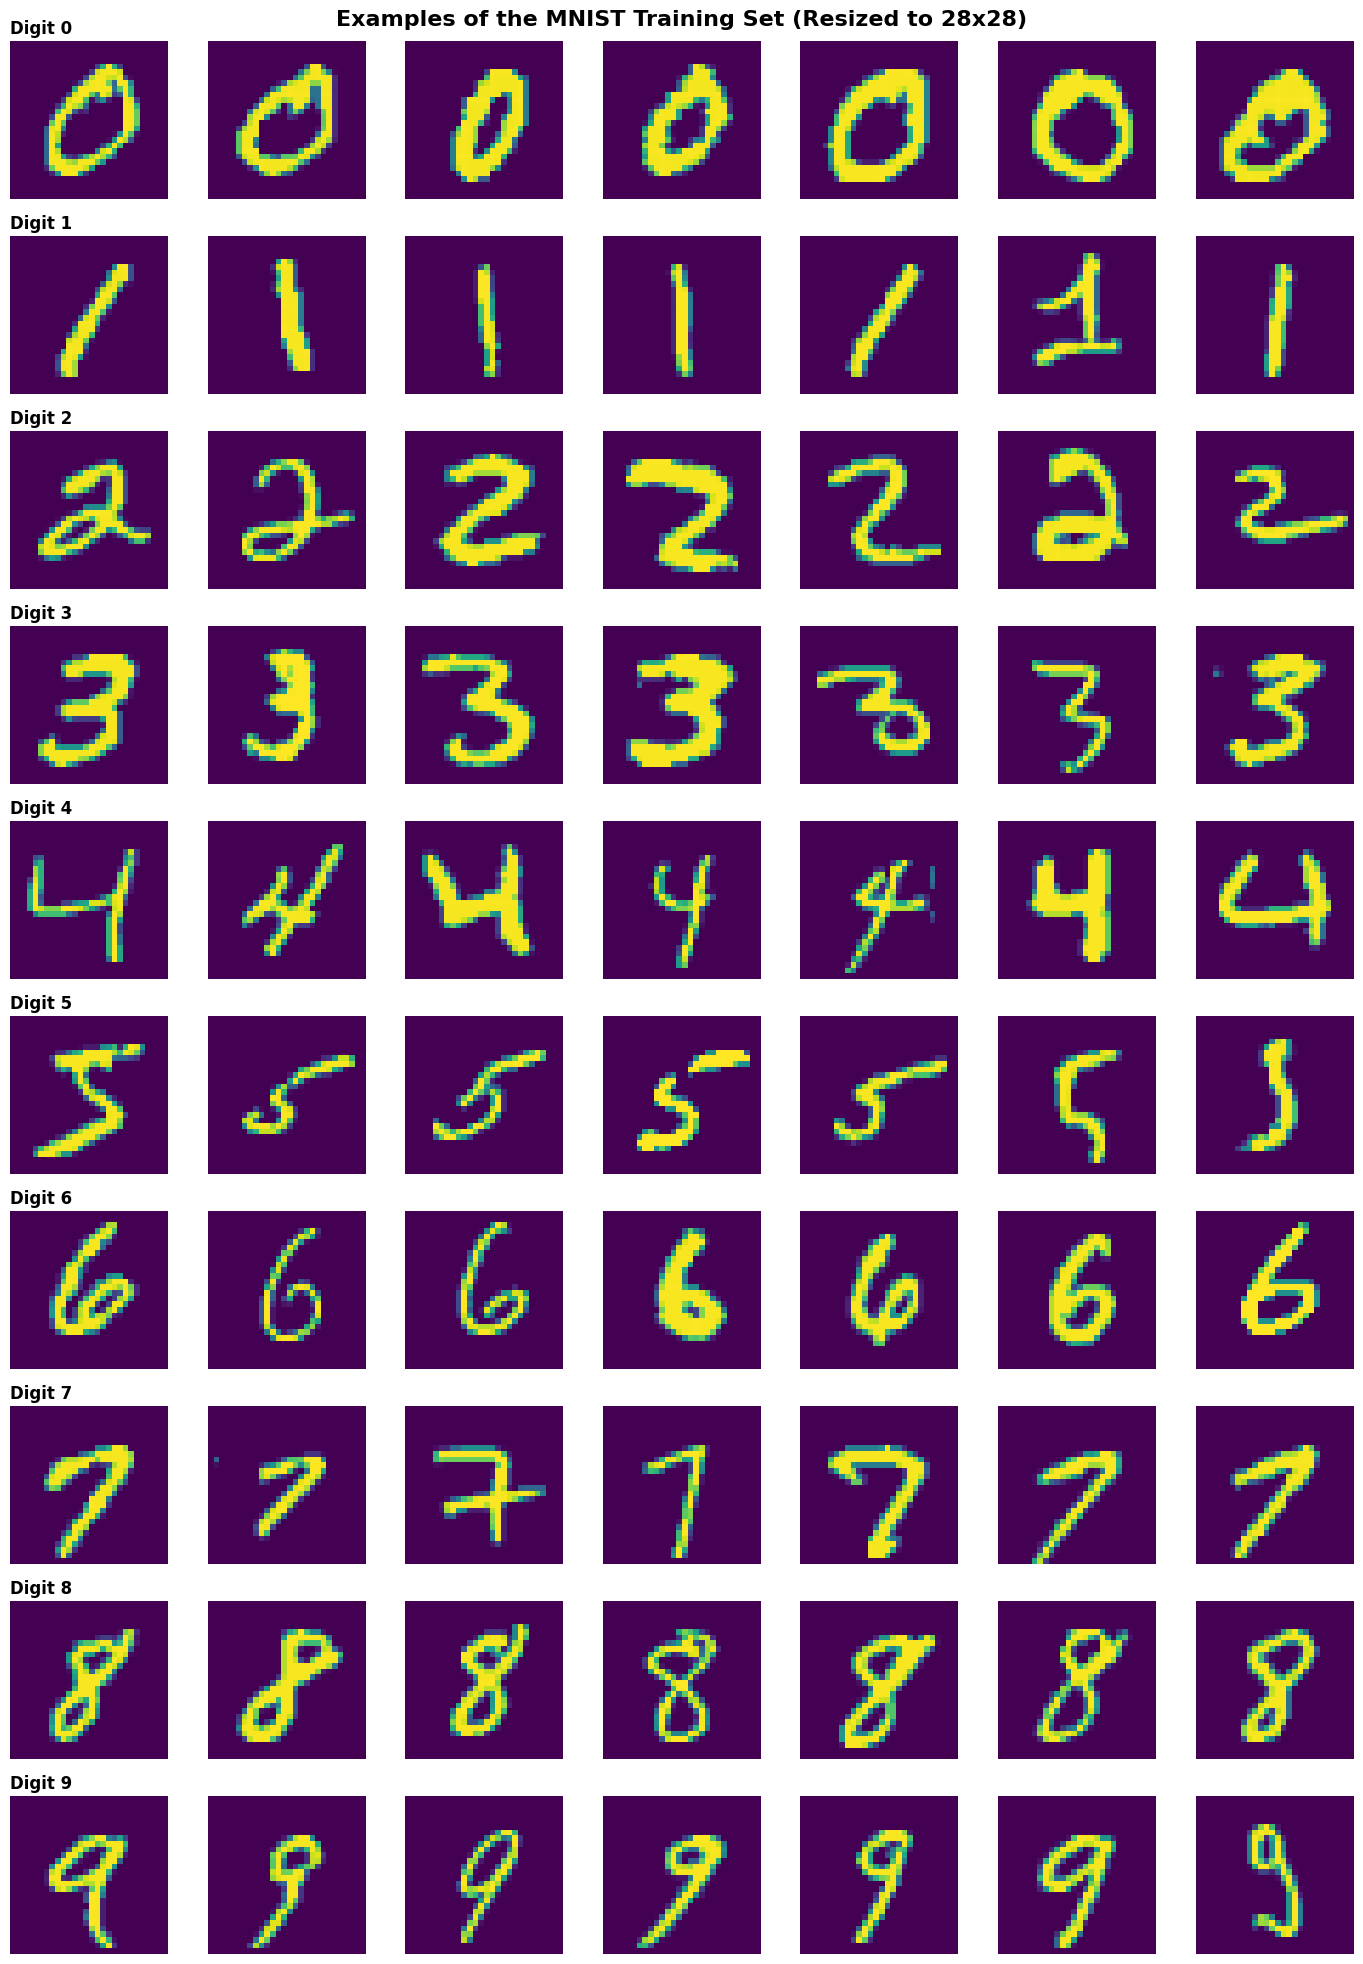

In [15]:
def resize_images(images, new_size=(28, 28)):
    """
    Resize a batch of images to a new size using OpenCV.

    Parameters:
    - images: A numpy array of shape (num_images, height, width) containing the images to be resized.
    - new_size: A tuple (new_height, new_width) specifying the desired size of the output images.

    Returns:
    - A numpy array of shape (num_images, new_height, new_width) containing the resized images.
    """


    num_imgs = images.shape[0]
    new_width, new_height = new_size


    resized = np.zeros((num_imgs, new_height, new_width), dtype=np.float32)
    for i in range(num_imgs):
        resized[i] = cv2.resize(images[i].astype(np.float32), (new_width, new_height))
    return resized

NEW_WIDTH, NEW_HEIGHT = 28, 28
x_train_resized = resize_images(x_train_pre,    (NEW_WIDTH, NEW_HEIGHT))
x_val_resized = resize_images(x_val_pre,        (NEW_WIDTH, NEW_HEIGHT))


show_examples(x_train_resized, y_train, num_classes=10, num_photos=7, title=f"Examples of the MNIST Training Set (Resized to {NEW_WIDTH}x{NEW_HEIGHT})")



### Normalization

Normalization is applied to the images to scale the pixel values to the range [0, 1].

In [16]:
MAX_VAL = 255     # Each pixel value in the MNIST dataset is an integer between 0 and 255.

x_train_normalized = x_train_resized / MAX_VAL
x_val_normalized   = x_val_resized / MAX_VAL

### Binarization

Binarization is applied to the images to convert them into binary images. This is done by setting a threshold value, and any pixel value above this threshold is set to 1 (white), while any pixel value below the threshold is set to 0 (black).

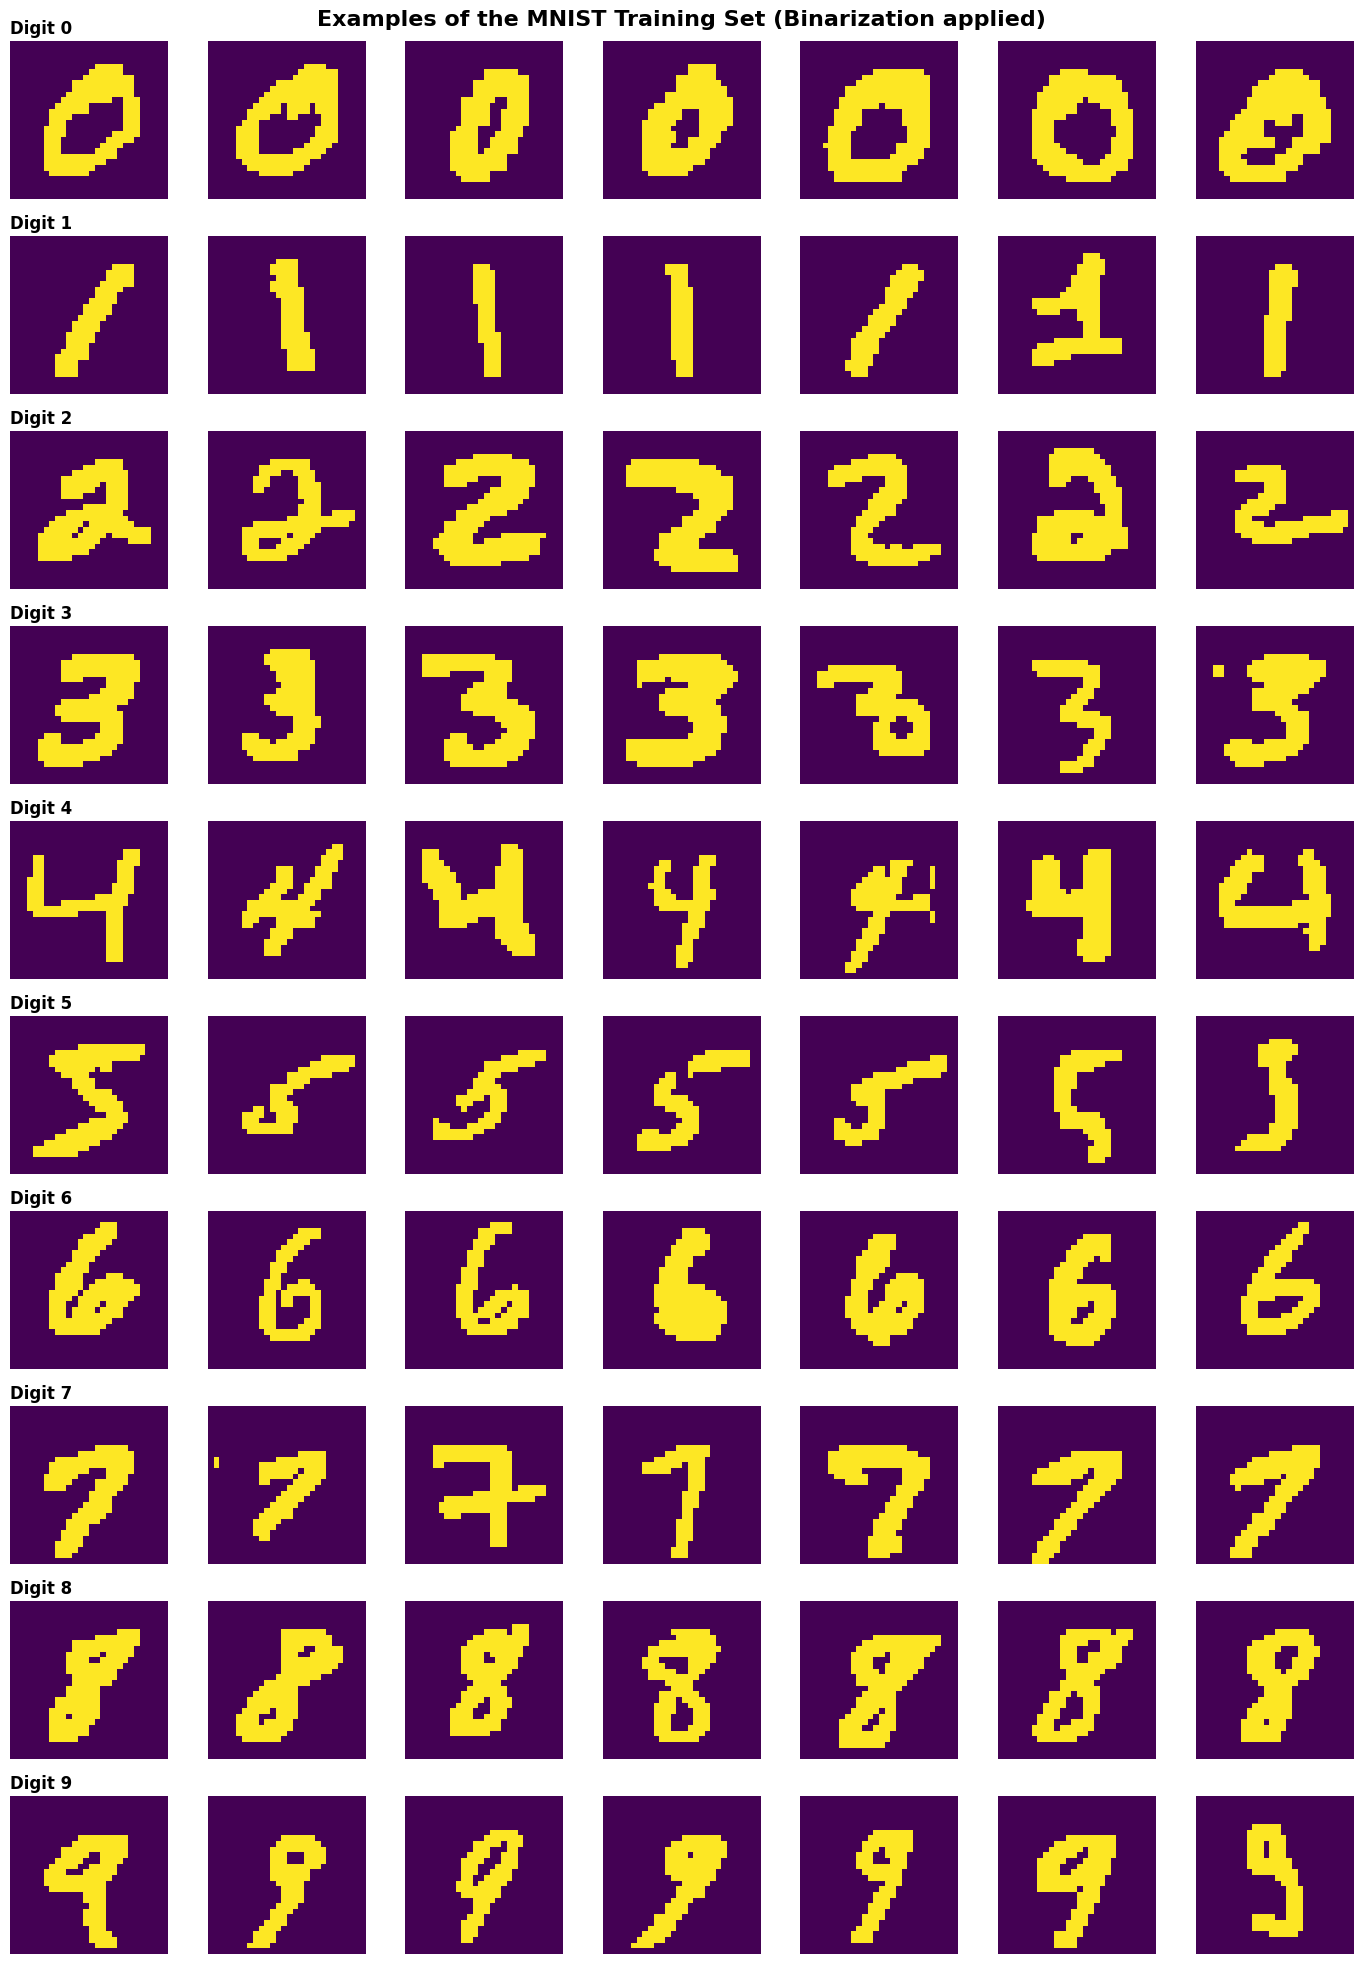

In [17]:
THRESHOLD = 0.5

x_train_bin = np.where(x_train_resized  > THRESHOLD, 1.0, 0.0).astype(np.float32)
x_val_bin   = np.where(x_val_resized    > THRESHOLD, 1.0, 0.0).astype(np.float32)

show_examples(x_train_bin, y_train, num_classes=10, num_photos=7, title="Examples of the MNIST Training Set (Binarization applied)")

### Creating DataLoaders

The DataLoaders are created for both the training and validation sets. The training DataLoader is set to shuffle the data, while the validation DataLoader is not shuffled.

Since the Bernoulli Decoder needs binary input and the Gaussian Decoder needs continuous input, two different DataLoaders are created for the training set: one for the Bernoulli Decoder and one for the Gaussian Decoder.

In [18]:
BATCH_SIZE_TRAIN = 32
BATCH_SIZE_VAL = 100

set_seed(SEED)

bernoulli_train_dataset   = TensorDataset(torch.from_numpy(x_train_bin),  torch.from_numpy(y_train)   )
bernoulli_test_dataset    = TensorDataset(torch.from_numpy(x_val_bin),    torch.from_numpy(y_val)     )

bernoulli_trainloader = DataLoader(bernoulli_train_dataset, batch_size=BATCH_SIZE_TRAIN, shuffle=True )
bernoulli_testloader  = DataLoader(bernoulli_test_dataset,  batch_size=BATCH_SIZE_VAL,   shuffle=False)

set_seed(SEED)

gaussian_train_dataset   = TensorDataset(torch.from_numpy(x_train_normalized),  torch.from_numpy(y_train)   )
gaussian_test_dataset    = TensorDataset(torch.from_numpy(x_val_normalized),    torch.from_numpy(y_val)     )

gaussian_trainloader = DataLoader(gaussian_train_dataset, batch_size=BATCH_SIZE_TRAIN, shuffle=True )
gaussian_testloader  = DataLoader(gaussian_test_dataset,  batch_size=BATCH_SIZE_VAL,   shuffle=False)

### Create the VAE

The model created in `vae.py` is used to create the Variational Autoencoder (VAE) model.
If possible, the model is moved to the GPU for faster training.

In [19]:
LATENT_DIM = 10

gaussian_encoder = GaussianEncoder(input_dim=NEW_WIDTH*NEW_HEIGHT, hidden_dim=512, latent_dim=LATENT_DIM)
gaussian_decoder    = GaussianDecoder   (latent_dim=LATENT_DIM, hidden_dim=512, output_dim=NEW_WIDTH*NEW_HEIGHT)
bernoulli_decoder  = BernoulliDecoder  (latent_dim=LATENT_DIM, hidden_dim=512, output_dim=NEW_WIDTH*NEW_HEIGHT)

gaussian_vae    = VAE(gaussian_encoder, gaussian_decoder).to(device)
bernoulli_vae  = VAE(gaussian_encoder, bernoulli_decoder).to(device)

### Defining loss, optimizer and LR scheduler

The loss function is defined (see its comments for details).

The optimizer is defined using the Adam optimizer.

A scheduler is defined to reduce the learning rate when the validation loss plateaus. The scheduler is set to monitor the validation loss and reduce the learning rate by a factor of 0.5 if the validation loss does not improve for 5 consecutive epochs. The minimum learning rate is set to 0.0001.

In [20]:
def loss_gaussian_vae(x, mu_latent, log_var_latent, mu_reconstruction, std_reconstruction=0.5):
    """
    Calculates the loss function for a Gaussian VAE.

    Parameters:
    - x: The original input data. Dimensions: (batch_size, input_dim)
    - mu_latent: The mean calculated by the encoder (mu_theta(x)). Dimensions: (batch_size, latent_dim)
    - log_var_latent: The logarithm of the variance from the encoder. Dimensions: (batch_size, latent_dim)
    - mu_reconstruction: The mean of the reconstruction distribution (p_theta(x|z)). Dimensions: (batch_size, input_dim)
    - std_reconstruction: The standard deviation of the reconstruction distribution.

    Returns:
    - total_loss: The total loss to minimize, which is the sum of the reconstruction loss and the KL divergence loss.
    - recon_loss: The reconstruction loss term.
    - kl_loss: The KL divergence loss term.
    """
    x_flattened = x.view(x.size(0), -1)  # Flatten x to match dimensions with mu_reconstruction

    # 1. Reconstruction Term: (1 / (2 * sigma^2)) * ||x - mu_phi(z)||^2
    recon_loss = F.mse_loss(mu_reconstruction, x_flattened, reduction='sum')
    recon_loss = recon_loss / (2.0 * std_reconstruction ** 2)

    # 2. KL Divergence Term (Closed-form solution for Gaussians)
    kl_loss = -0.5 * torch.sum(1 + log_var_latent - mu_latent.pow(2) - log_var_latent.exp())

    # Total loss to minimize
    total_loss = recon_loss + kl_loss
    
    return total_loss, recon_loss, kl_loss


def loss_bernoulli_vae(x, mu_latent, log_var_latent, p_reconstruction):
    """
    Calculates the loss function for a Bernoulli VAE.

    Parameters:
    - x: The original input data. Dimensions: (batch_size, input_dim)
    - mu_latent: The mean calculated by the encoder (mu_theta(x)). Dimensions: (batch_size, latent_dim)
    - log_var_latent: The logarithm of the variance from the encoder. Dimensions: (batch_size, latent_dim)
    - p_reconstruction: The probability of the reconstruction distribution (p_theta(x|z)). Dimensions: (batch_size, input_dim)

    Returns:
    - total_loss: The total loss to minimize, which is the sum of the reconstruction loss and the KL divergence loss.
    - recon_loss: The reconstruction loss term.
    - kl_loss: The KL divergence loss term.
    """
    x_flattened = x.view(x.size(0), -1)  # Flatten x to match dimensions with p_reconstruction

    # 1. Reconstruction Term: Binary Cross-Entropy Loss
    recon_loss = F.binary_cross_entropy(p_reconstruction, x_flattened, reduction='sum')

    # 2. KL Divergence Term (Closed-form solution for Gaussians)
    kl_loss = -0.5 * torch.sum(1 + log_var_latent - mu_latent.pow(2) - log_var_latent.exp())

    # Total loss to minimize
    total_loss = recon_loss + kl_loss
    
    return total_loss, recon_loss, kl_loss

In [21]:
optimizer_gaussian = torch.optim.Adam(gaussian_vae.parameters(), lr=0.002)
scheduler_gaussian = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_gaussian, mode='min', factor=0.5, patience=5, threshold=0.001, min_lr=0.0001
)

optimizer_bernoulli = torch.optim.Adam(bernoulli_vae.parameters(), lr=0.002)
scheduler_bernoulli = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_bernoulli, mode='min', factor=0.5, patience=5, threshold=0.001, min_lr=0.0001
)

### Training the model

In [22]:
def train_model(model, optimizer, scheduler, loss_function, trainloader, testloader, num_epochs=20, model_name="VAE"):
    """
    Trains the given VAE model.

    Parameters:
    - model: The VAE model to train.
    - optimizer: The optimizer for updating model weights.
    - scheduler: The learning rate scheduler.
    - loss_function: The loss function to use (either Gaussian or Bernoulli).
    - trainloader: DataLoader for the training dataset.
    - testloader: DataLoader for the validation/test dataset.
    - num_epochs: Number of epochs to train the model.
    - model_name: Name of the model (for logging purposes).

    Returns:
    - history: A dictionary containing training and validation losses over time. It contains:
        - 'train_recon_loss': List of average reconstruction losses for each training batch.
        - 'train_kl_loss': List of average KL divergence losses for each training batch.
        - 'total_steps_counter': List of step numbers corresponding to each training batch.
        - 'periodic_val_recon_loss': List of average reconstruction losses for validation batches (every PERIODIC_VALIDATION_INTERVAL steps).
        - 'periodic_val_kl_loss': List of average KL divergence losses for validation batches (every PERIODIC_VALIDATION_INTERVAL steps).
        - 'periodic_val_steps': List of step numbers corresponding to each validation batch.
    """

    print(f"Training model: {model_name} for {num_epochs} epochs on device: {device}")



    PERIODIC_VALIDATION_INTERVAL = 100  # Perform validation every 100 weight updates

    history = {
        'train_recon_loss': [], 'train_kl_loss': [],    # In each batch, the average reconstruction loss and KL divergence loss for that batch will be saved.
        'total_steps_counter': [],                      # In each batch, the step number will be saved, which will be used to plot the loss curves.
        'periodic_val_recon_loss': [], 'periodic_val_kl_loss': [],  # Every PERIODIC_VALIDATION_INTERVAL weight updates, the average reconstruction loss and KL divergence loss on a validation batch will be saved.
        'periodic_val_steps': []        # Every PERIODIC_VALIDATION_INTERVAL weight updates, the step number will be saved.
    }

    current_step_number = 0  # Tracks the number of weight updates performed so far

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_epoch_loss = 0.0
        
        for batch_idx, (data, _) in enumerate(trainloader):
            data = data.to(device)
            batch_size = data.shape[0]
            optimizer.zero_grad()
            
            # Forward pass
            recon_batch, mu, log_var = model(data)
            
            # Calculate loss
            loss, recon_loss, kl_loss = loss_function(data, mu, log_var, recon_batch)
            
            # Backward pass (Backpropagation)
            loss.backward()
            
            # Update weights
            optimizer.step()
            
            # Save metrics for this batch
            running_epoch_loss += loss.item()
            history['train_recon_loss'].append(recon_loss.item() / batch_size)
            history['train_kl_loss'].append(kl_loss.item() / batch_size)
            
            current_step_number += 1
            history['total_steps_counter'].append(current_step_number)

            # --- Fast Validation every PERIODIC_VALIDATION_INTERVAL weight updates ---
            if current_step_number % PERIODIC_VALIDATION_INTERVAL == 0:
                model.eval()
                with torch.no_grad():
                    # Fast Validation => Only a single batch from the testloader is used to save time
                    val_data, _ = next(iter(testloader))
                    val_batch_size = val_data.shape[0]
                    val_data = val_data.to(device)
                    
                    v_recon, v_mu, v_log_var = model(val_data)
                    _, v_recon_loss, v_kl_loss = loss_function(val_data, v_mu, v_log_var, v_recon)
                    
                    # Save average loss for this validation batch
                    history['periodic_val_recon_loss'].append(v_recon_loss.item() / val_batch_size)
                    history['periodic_val_kl_loss'].append(v_kl_loss.item() / val_batch_size)
                    history['periodic_val_steps'].append(current_step_number)
                
                model.train()  # Switch back to training mode

        # --- End of Epoch: Full Evaluation on the Test Set ---
        model.eval()
        total_test_loss = 0.0
        
        with torch.no_grad():
            for test_data, _ in testloader:
                test_data = test_data.to(device)
                t_recon, t_mu, t_log_var = model(test_data)
                t_loss, _, _ = loss_function(test_data, t_mu, t_log_var, t_recon)
                total_test_loss += t_loss.item()
                
        epoch_train_avg = running_epoch_loss / len(trainloader.dataset)
        epoch_test_avg = total_test_loss / len(testloader.dataset)
        
        # Update learning rate based on average training loss
        scheduler.step(epoch_train_avg)
        
        print(f"====> Epoch: {epoch} | Avg Train Loss: {epoch_train_avg:.4f} | Test Loss: {epoch_test_avg:.4f}")

    return history


set_seed(SEED)
gaussian_vae_history    = train_model(gaussian_vae,     optimizer_gaussian,     scheduler_gaussian,     loss_gaussian_vae,  gaussian_trainloader,   gaussian_testloader,    num_epochs=20, model_name="Gaussian VAE")
print("\n\n")
set_seed(SEED)
bernoulli_vae_history  = train_model(bernoulli_vae,   optimizer_bernoulli,   scheduler_bernoulli,   loss_bernoulli_vae, bernoulli_trainloader, bernoulli_testloader,  num_epochs=20, model_name="Bernoulli VAE")

Training model: Gaussian VAE for 20 epochs on device: cuda
====> Epoch: 1 | Avg Train Loss: 76.6737 | Test Loss: 57.6512
====> Epoch: 2 | Avg Train Loss: 60.9866 | Test Loss: 55.2626
====> Epoch: 3 | Avg Train Loss: 58.3395 | Test Loss: 53.6060
====> Epoch: 4 | Avg Train Loss: 56.6816 | Test Loss: 52.0787
====> Epoch: 5 | Avg Train Loss: 55.6104 | Test Loss: 51.8989
====> Epoch: 6 | Avg Train Loss: 54.8278 | Test Loss: 52.0732
====> Epoch: 7 | Avg Train Loss: 54.3199 | Test Loss: 51.1055
====> Epoch: 8 | Avg Train Loss: 53.8835 | Test Loss: 50.9336
====> Epoch: 9 | Avg Train Loss: 53.4638 | Test Loss: 50.1216
====> Epoch: 10 | Avg Train Loss: 53.0253 | Test Loss: 49.3408
====> Epoch: 11 | Avg Train Loss: 52.8187 | Test Loss: 49.8052
====> Epoch: 12 | Avg Train Loss: 52.5190 | Test Loss: 50.0621
====> Epoch: 13 | Avg Train Loss: 52.2924 | Test Loss: 48.4995
====> Epoch: 14 | Avg Train Loss: 52.1207 | Test Loss: 49.4454
====> Epoch: 15 | Avg Train Loss: 51.8906 | Test Loss: 49.0534
====>

### Evaluating the model

In order to evaluate the model, we will first generate some plots.
- The two loss components (reconstruction loss vs KL divergence) are plotted for both the training and validation sets.
- The total loss of the training and validation sets is plotted.

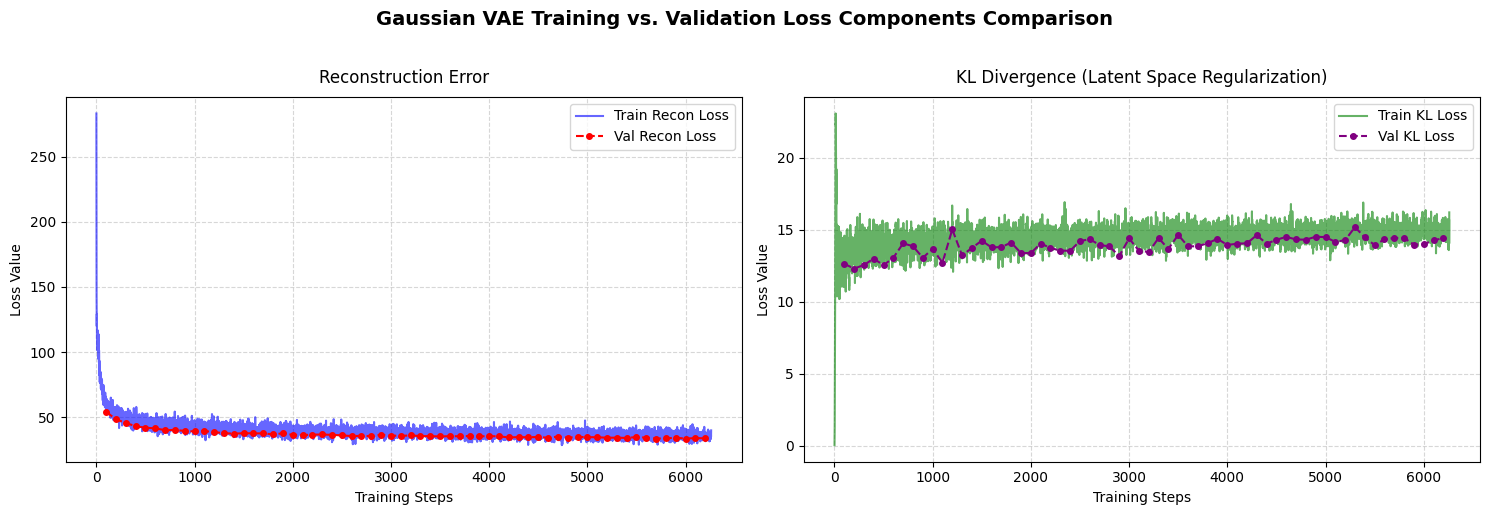

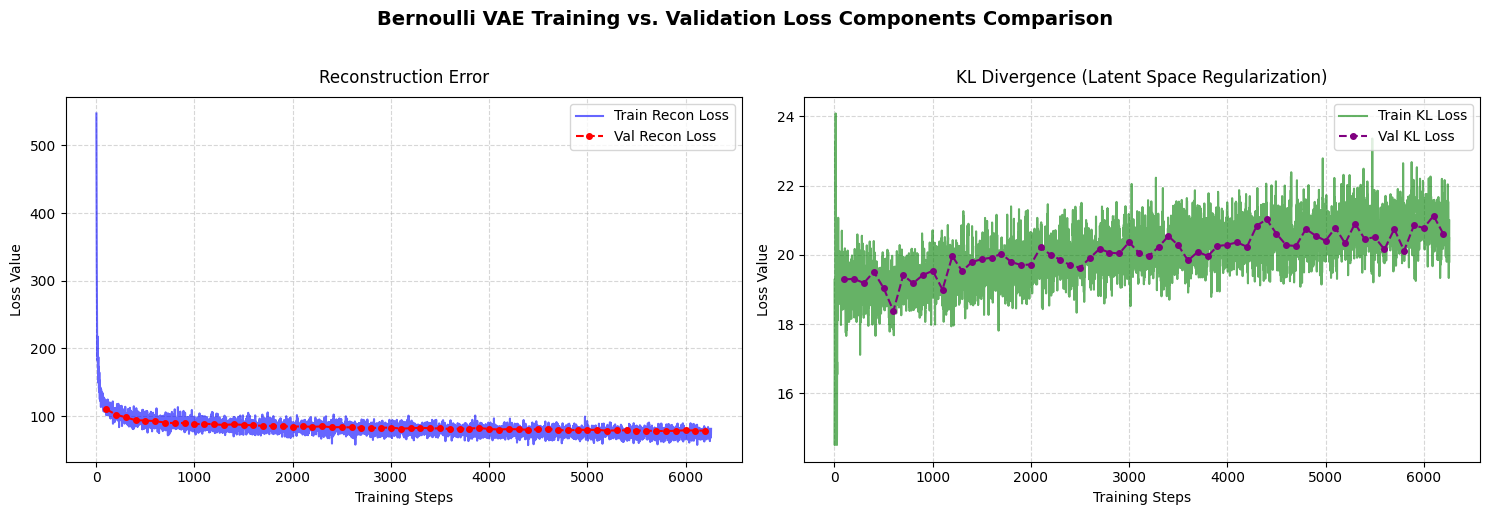

In [23]:
gaussian_vae.eval()
bernoulli_vae.eval()


def plot_loss_components(history, model_name="VAE"):
    """
    Plots the training and validation loss components (Reconstruction Loss and KL Divergence) for a given VAE model.

    Parameters:
    - history: The corresponding history dictionary returned by the train_model function.
    - model_name: Name of the model (for title purposes).
    """


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), dpi=100)
    fig.suptitle(f'{model_name} Training vs. Validation Loss Components Comparison', fontsize=14, fontweight='bold', y=1.02)

    # ---------------------------------------------------------------------
    # LEFT PLOT: Reconstruction Loss (Train vs. Validation)
    # ---------------------------------------------------------------------
    # Continuous line for frequent training steps
    ax1.plot(history['total_steps_counter'], history['train_recon_loss'], 
            color='blue', alpha=0.6, label='Train Recon Loss')

    # Dashed line with markers for periodic validation steps
    ax1.plot(history['periodic_val_steps'], history['periodic_val_recon_loss'], 
            color='red', linestyle='--', marker='o', markersize=4, label='Val Recon Loss')

    ax1.set_title('Reconstruction Error', fontsize=12, pad=10)
    ax1.set_xlabel('Training Steps', fontsize=10)
    ax1.set_ylabel('Loss Value', fontsize=10)
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper right')

    # ---------------------------------------------------------------------
    # RIGHT PLOT: KL Divergence Loss (Train vs. Validation)
    # ---------------------------------------------------------------------
    # Continuous line for frequent training steps
    ax2.plot(history['total_steps_counter'], history['train_kl_loss'], 
            color='green', alpha=0.6, label='Train KL Loss')

    # Dashed line with markers for periodic validation steps
    ax2.plot(history['periodic_val_steps'], history['periodic_val_kl_loss'], 
            color='purple', linestyle='--', marker='o', markersize=4, label='Val KL Loss')

    ax2.set_title('KL Divergence (Latent Space Regularization)', fontsize=12, pad=10)
    ax2.set_xlabel('Training Steps', fontsize=10)
    ax2.set_ylabel('Loss Value', fontsize=10)
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='upper right')

    # Adjust layout to prevent overlapping text
    plt.tight_layout()
    plt.show()

plot_loss_components(gaussian_vae_history,      model_name="Gaussian VAE")
plot_loss_components(bernoulli_vae_history,     model_name="Bernoulli VAE")

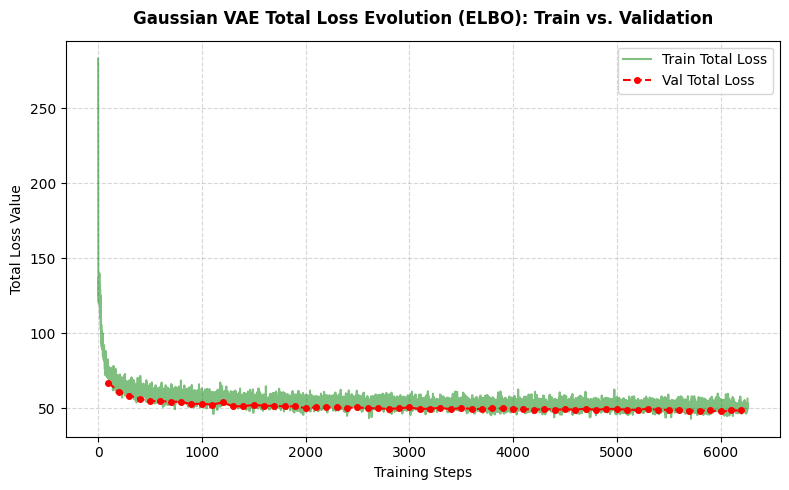

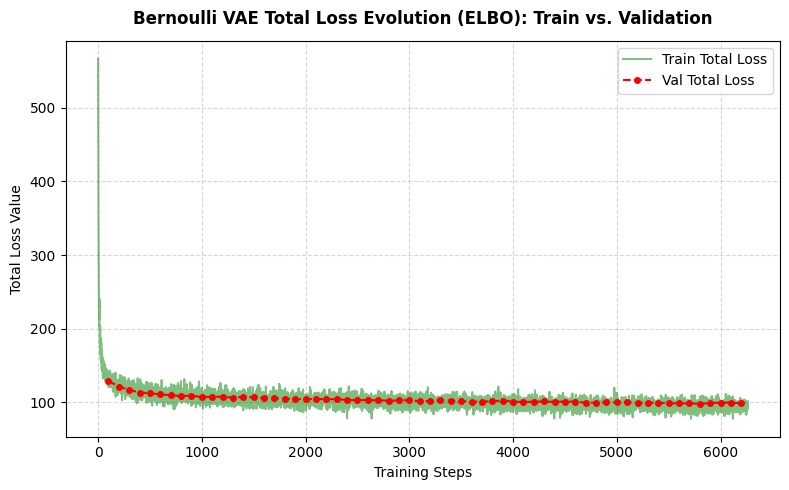

In [24]:
gaussian_vae.eval()
bernoulli_vae.eval()

def plot_total_loss(history, model_name="VAE"):
    """
    Plots the total loss (ELBO) for both training and validation phases of a given VAE model.

    Parameters:
    - history: The corresponding history dictionary returned by the train_model function.
    - model_name: Name of the model (for title purposes).
    """

    train_total_loss =  [recon + kl for recon, kl in zip(history['train_recon_loss'], history['train_kl_loss'])]
    val_total_loss =    [recon + kl for recon, kl in zip(history['periodic_val_recon_loss'], history['periodic_val_kl_loss'])]

    # Create the figure
    plt.figure(figsize=(8, 5), dpi=100)

    # Continuous line for frequent training steps
    plt.plot(history['total_steps_counter'], train_total_loss, 
            color='green', alpha=0.5, label='Train Total Loss')

    # Disconnected horizontal dashes for periodic validation steps
    plt.plot(history['periodic_val_steps'], val_total_loss, 
            color='red', linestyle='--', marker='o', markersize=4, label='Val Total Loss')

    # Aesthetics and labels
    plt.title(f'{model_name} Total Loss Evolution (ELBO): Train vs. Validation', fontsize=12, fontweight='bold', pad=12)
    plt.xlabel('Training Steps', fontsize=10)
    plt.ylabel('Total Loss Value', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

plot_total_loss(gaussian_vae_history, model_name="Gaussian VAE")
plot_total_loss(bernoulli_vae_history, model_name="Bernoulli VAE")

### Visualizating the image reconstruction

We will visualize the image reconstruction both for the training and validation sets. The original images will be shown alongside their reconstructed versions.

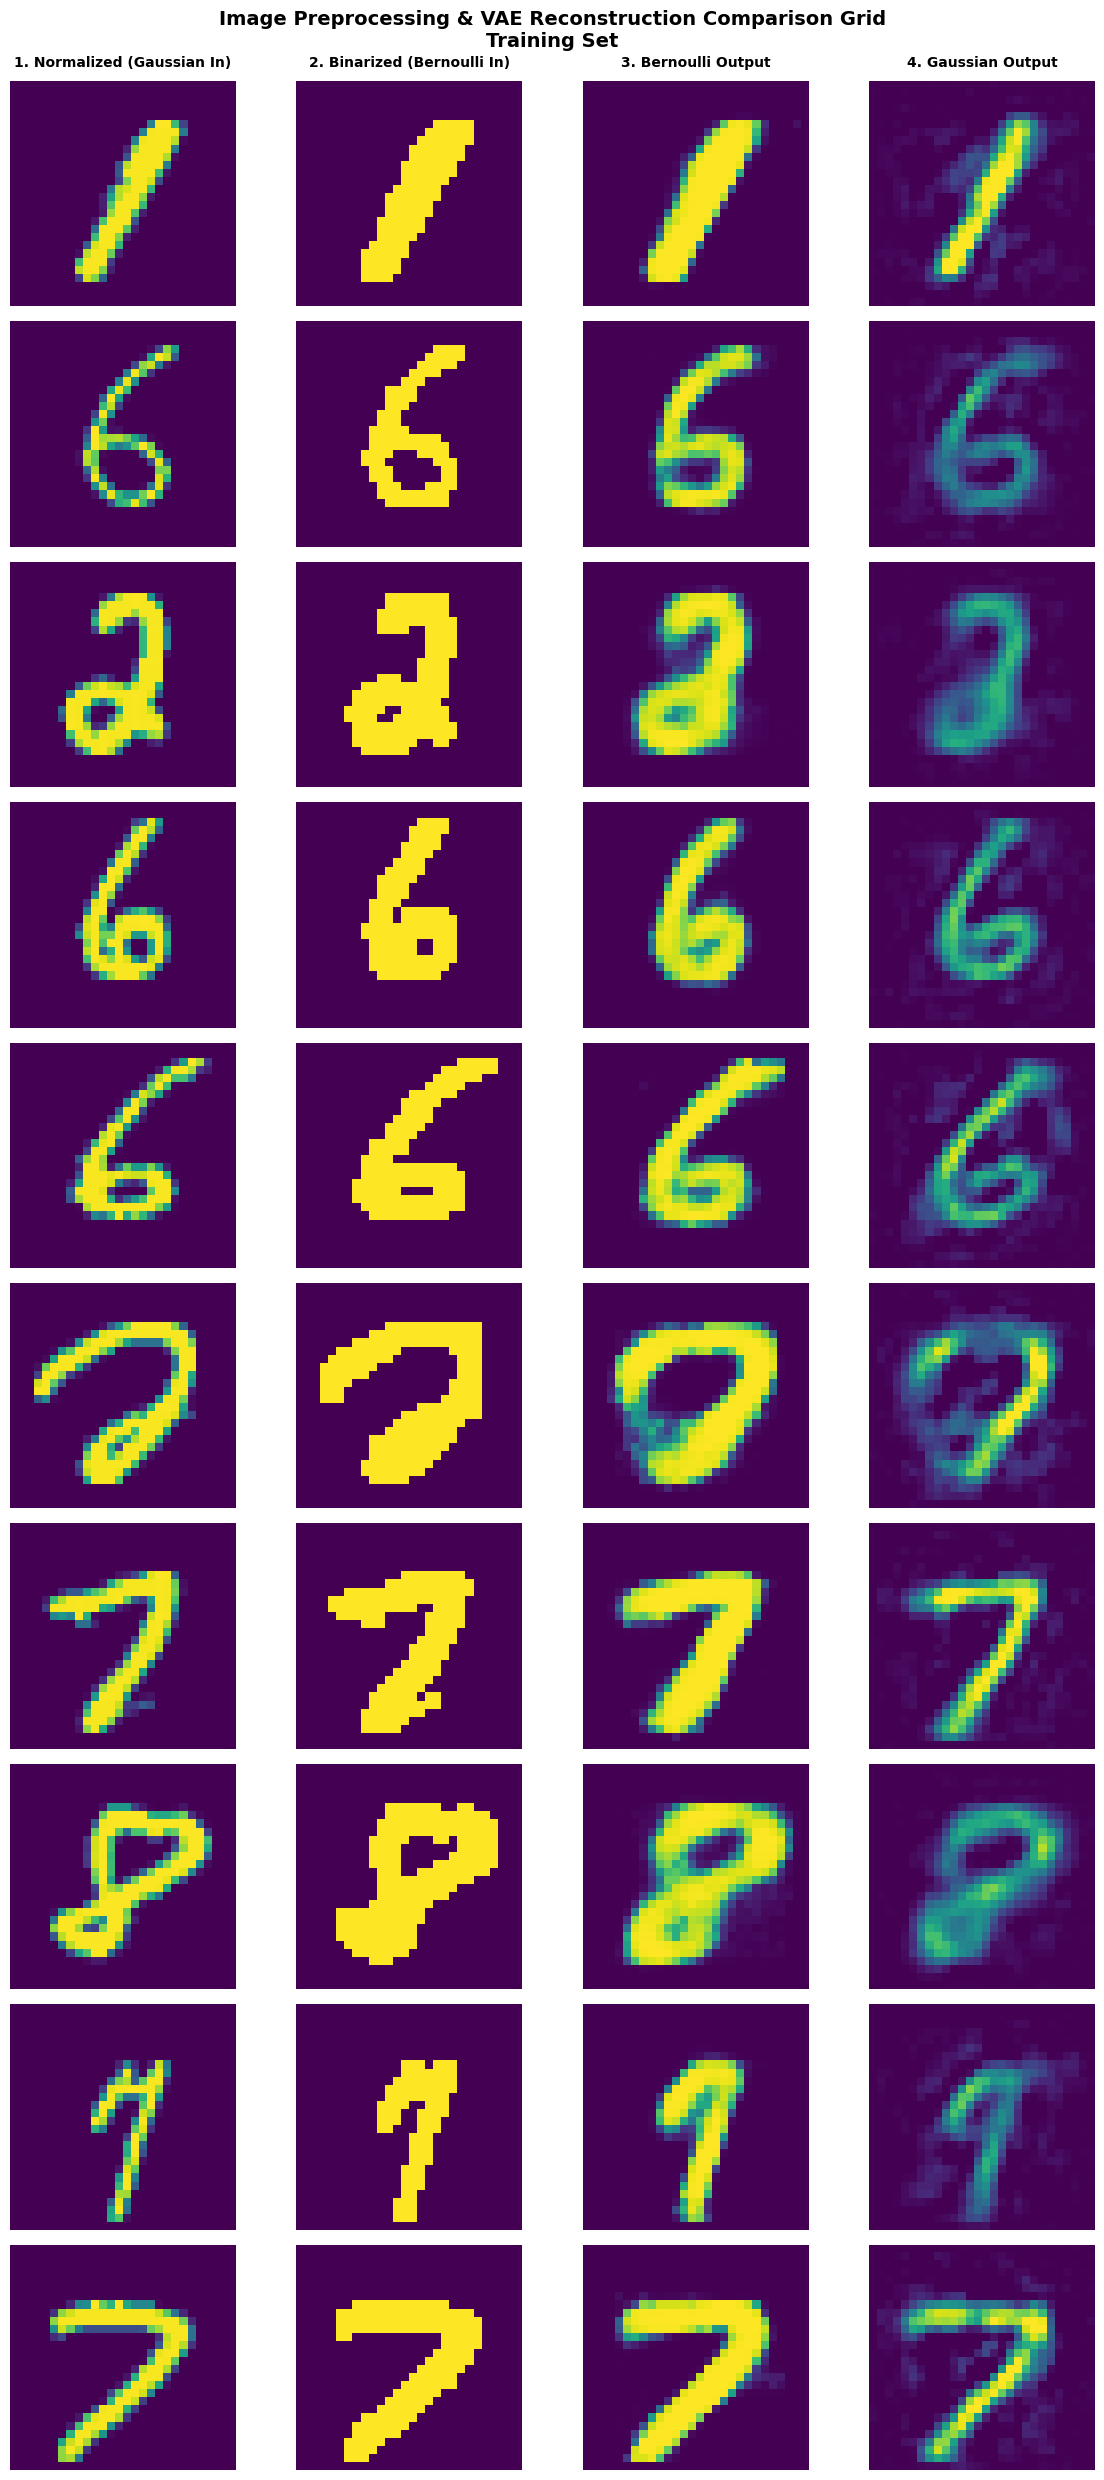

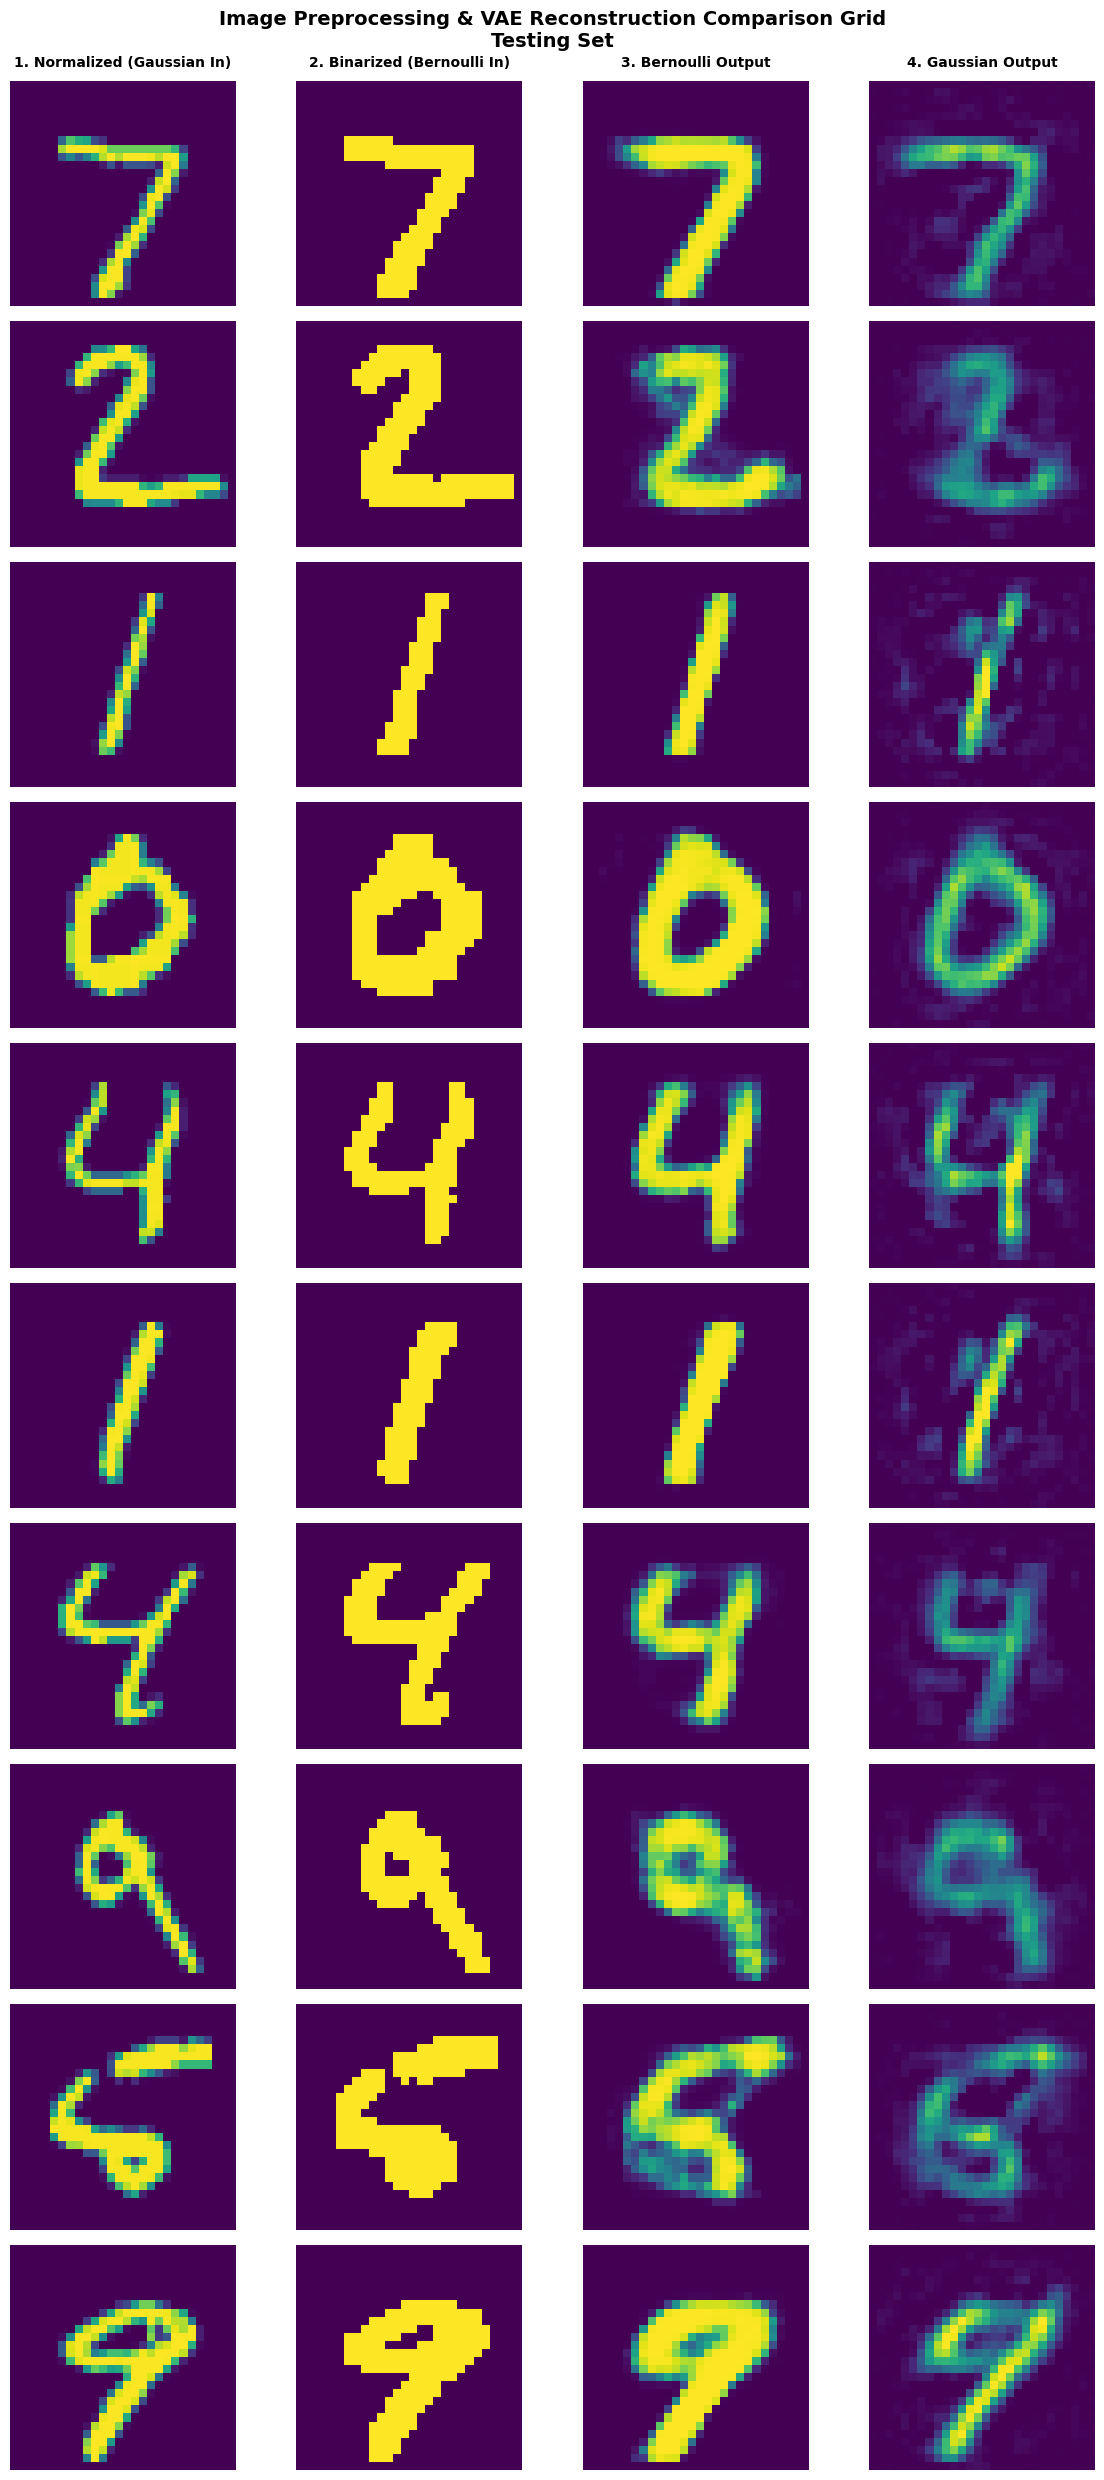

In [25]:
def compare_vae_outputs(gaussian_loader, bernoulli_loader, gaussian_model, bernoulli_model, num_images=5, subtitle=""):
    """
    Plots a grid comparing normalized and binarized images 
    against reconstructions from both Gaussian and Bernoulli VAEs, 
    using separate dataloaders for each preprocessing pipeline.

    Parameters:
    - gaussian_loader: DataLoader for the normalized images (input to Gaussian VAE).
    - bernoulli_loader: DataLoader for the binarized images (input to Bernoulli VAE).
    - gaussian_model: The trained Gaussian VAE model.
    - bernoulli_model: The trained Bernoulli VAE model.
    - num_images: Number of images to visualize in the grid (default is 5).
    - subtitle: Optional subtitle for the entire figure (default is an empty string).
    """
    gaussian_model.eval()
    bernoulli_model.eval()
    
    # Use a fixed seed to ensure both iterators fetch the exact same batch of samples
    set_seed(SEED)
    gaussian_images, _  = next(iter(gaussian_loader))
    set_seed(SEED)
    bernoulli_images, _ = next(iter(bernoulli_loader))
    
    gaussian_images = gaussian_images.to(device)
    bernoulli_images = bernoulli_images.to(device)
    
    with torch.no_grad():
        gaussian_recon, _, _ = gaussian_model(gaussian_images)
        bernoulli_recon, _, _ = bernoulli_model(bernoulli_images)
        
    headers = ['1. Normalized (Gaussian In)', '2. Binarized (Bernoulli In)', '3. Bernoulli Output', '4. Gaussian Output']
    

    fig, axes = plt.subplots(num_images, len(headers), figsize=(12, num_images * 2.5), dpi=100)
    fig.suptitle(f'Image Preprocessing & VAE Reconstruction Comparison Grid\n{subtitle}', 
                 fontsize=14, fontweight='bold', y=0.99)
    
    
    for row in range(num_images):
        img_norm = gaussian_images[row].cpu().numpy()
        img_bin = bernoulli_images[row].cpu().numpy()
        
        # --- Extract Model Outputs (Reshaped back to 2D matrices) ---
        img_bernoulli_out = bernoulli_recon[row].view(NEW_WIDTH, NEW_HEIGHT).cpu().numpy()
        img_gaussian_out = gaussian_recon[row].view(NEW_WIDTH, NEW_HEIGHT).cpu().numpy()
        
        # Consolidate the 4 states for the current row
        image_states = [img_norm, img_bin, img_bernoulli_out, img_gaussian_out]
        
        for col in range(len(headers)):
            ax = axes[row, col] if num_images > 1 else axes[col]
            
            # Use strict vmin/vmax to respect pixel value scales
            ax.imshow(image_states[col], cmap=CMAP, vmin=0, vmax=1)
            ax.axis('off')
            
            # Set headers only on the top row
            if row == 0:
                ax.set_title(headers[col], fontsize=10, fontweight='bold', pad=10)
                
    plt.tight_layout()
    plt.show()

NUM_IMAGES_TO_COMPARE = 10
compare_vae_outputs(gaussian_trainloader, bernoulli_trainloader, gaussian_vae, bernoulli_vae, num_images=NUM_IMAGES_TO_COMPARE, subtitle=f"Training Set")
compare_vae_outputs(gaussian_testloader, bernoulli_testloader, gaussian_vae, bernoulli_vae, num_images=NUM_IMAGES_TO_COMPARE, subtitle=f"Testing Set")


### Generating new images

Now, we will generate new images by sampling from the latent space of the VAE. The generated images will be displayed in a grid format.

It should be noted that, using these VAEs, we can't ask for a specific digit to be generated. The generated images will be random samples from the learned distribution in the latent space.

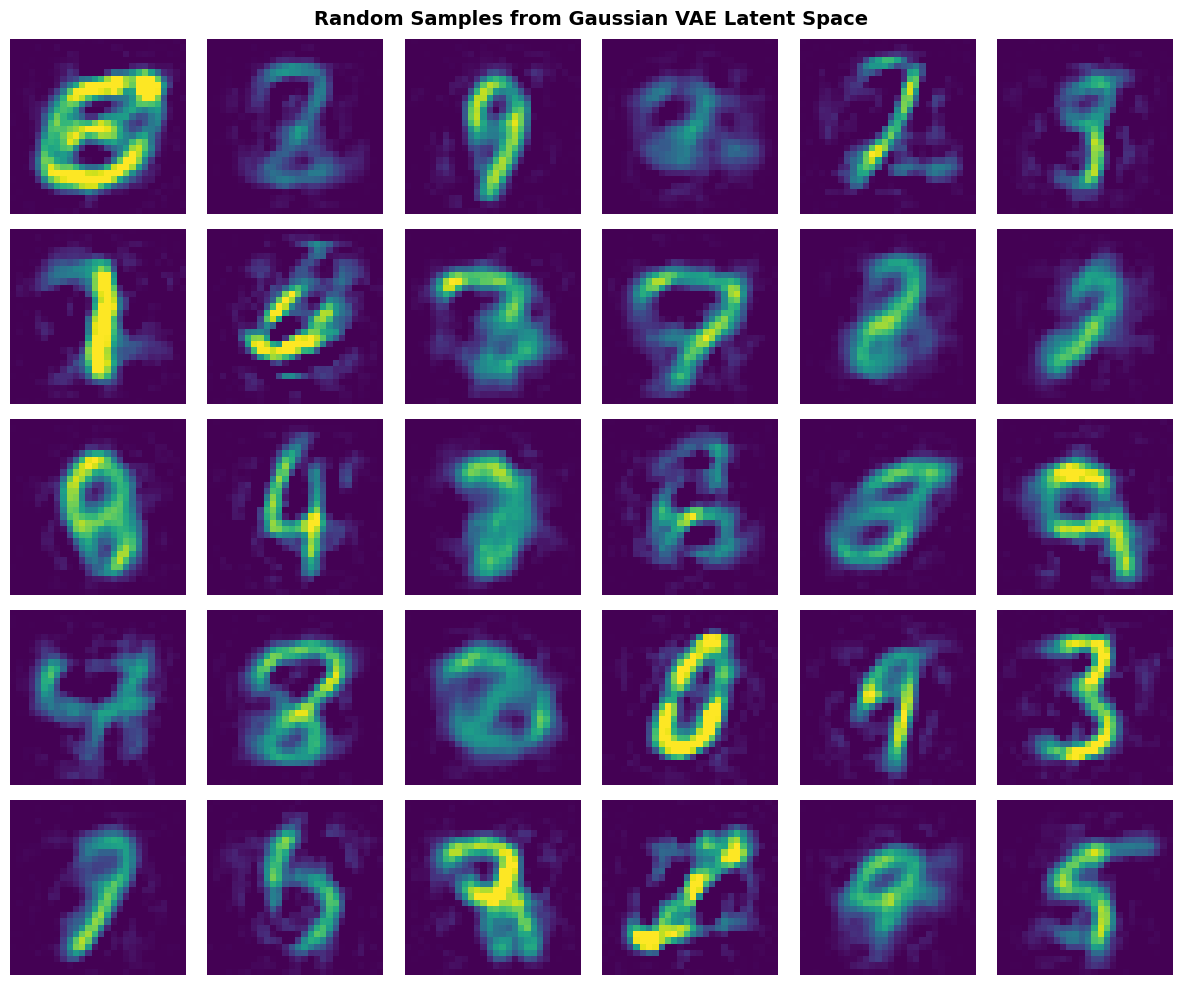

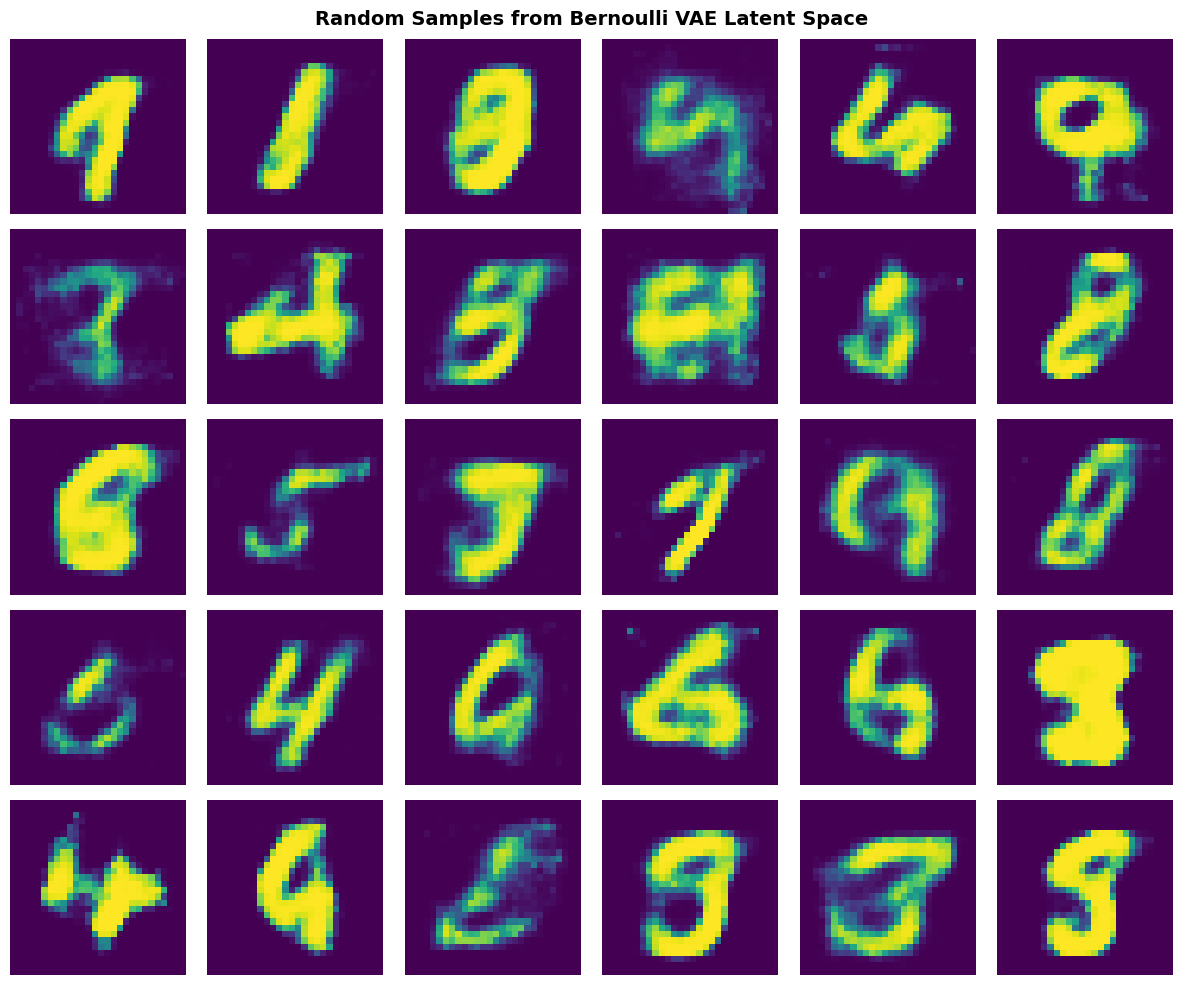

In [26]:
def generate_random_samples(model, latent_dim, num_samples=30, title="Random Samples from Latent Space"):
    """
    Generates random samples from the latent space of a given VAE model.
    It displays the generated samples in a grid format.

    Parameters:
    - model: The trained VAE model (either Gaussian or Bernoulli).
    - latent_dim: The dimensionality of the latent space.
    - num_samples: Number of random samples to generate (default is 30).

    """
    model.eval()

    # Generate random latent vectors from a standard normal distribution N(0, 1)
    with torch.no_grad():
        random_latent_vectors = torch.randn(num_samples, latent_dim).to(device)
        generated_images = model.decoder(random_latent_vectors)
        
    cols = int(math.ceil(math.sqrt(num_samples)))
    rows = int(math.ceil(num_samples / cols))

    # Create the grid plot
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2), dpi=100)
    fig.suptitle(title, fontsize=14, fontweight='bold', y=0.98)

    # Flatten the axes array for easy 1D iteration
    axes_flat = axes.flatten() if num_samples > 1 else [axes]

    for i in range(len(axes_flat)):
        if i < num_samples:
            # Reshape the flat vector back to a 2D matrix (assuming 14x14 based on your previous code)
            # Change to 28, 28 if your VAE architecture outputs standard MNIST size
            img = generated_images[i].view(NEW_HEIGHT, NEW_WIDTH).cpu().numpy()
            
            axes_flat[i].imshow(img, cmap=CMAP, vmin=0, vmax=1)
            axes_flat[i].axis('off')
        else:
            # Turn off extra empty subplots if num_images doesn't perfectly fill the grid
            axes_flat[i].axis('off')
            
    plt.tight_layout()
    plt.show()


NUM_RANDOM_SAMPLES = 30
generate_random_samples(gaussian_vae, latent_dim=LATENT_DIM, num_samples=NUM_RANDOM_SAMPLES, title="Random Samples from Gaussian VAE Latent Space")
generate_random_samples(bernoulli_vae, latent_dim=LATENT_DIM, num_samples=NUM_RANDOM_SAMPLES, title="Random Samples from Bernoulli VAE Latent Space")

As we can see from the generated images, the VAE has learned to capture the underlying structure of the handwritten digits and can generate new samples that resemble the training data. However, the generated images may not always be perfect and can sometimes be blurry or distorted, which is a common characteristic of generative models like VAEs.

When comparing the images generated by the Bernoulli Decoder and the Gaussian Decoder, we can observe that the Bernoulli Decoder tends to produce sharper images, while the Gaussian Decoder may produce smoother images. This is due to the different assumptions made by each decoder regarding the distribution of pixel values.

### Visualizing the latent space with t-SNE

The t-SNE algorithm is used to visualize the latent space of the VAE. The latent representations (mu) of the validation set are extracted and reduced to 2D using t-SNE. The resulting 2D points are then plotted, with each point colored according to its corresponding digit label.

In [41]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

def latent_space_tsne_visualization(vae_model, data_loader, title="t-SNE Visualization of VAE Latent Space", seed=42):
    """
    Visualizes the latent space of a VAE model using t-SNE.

    Parameters:
    - vae_model: The trained VAE model (either Gaussian or Bernoulli).
    - data_loader: DataLoader for the dataset to visualize.
    - title: Optional title for the plot (default is None).
    - seed: Random seed for reproducibility (default is 42).
    """
    vae_model.eval() 

    all_mu = []
    all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(device)
            
            mu, _ = vae_model.encoder(x_batch.view(x_batch.size(0), -1)) 
            
            all_mu.append(mu.cpu().numpy())
            all_labels.append(y_batch.numpy())

    all_mu = np.concatenate(all_mu, axis=0)         # Shape: (N, latent_dim)
    all_labels = np.concatenate(all_labels, axis=0) # Shape: (N,)

    tsne = TSNE(n_components=2, random_state=seed, perplexity=30, max_iter=1000)
    mu_2d = tsne.fit_transform(all_mu) # mu_2d now has shape (N, 2)

    # Create a scatter plot of the 2D t-SNE embeddings
    plt.figure(figsize=(10, 8), dpi=100)
    sns.scatterplot(x=mu_2d[:, 0], y=mu_2d[:, 1], hue=all_labels, palette='tab10', legend='full', alpha=0.7)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.legend(title='Digit Class', title_fontsize=12, fontsize=10, loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

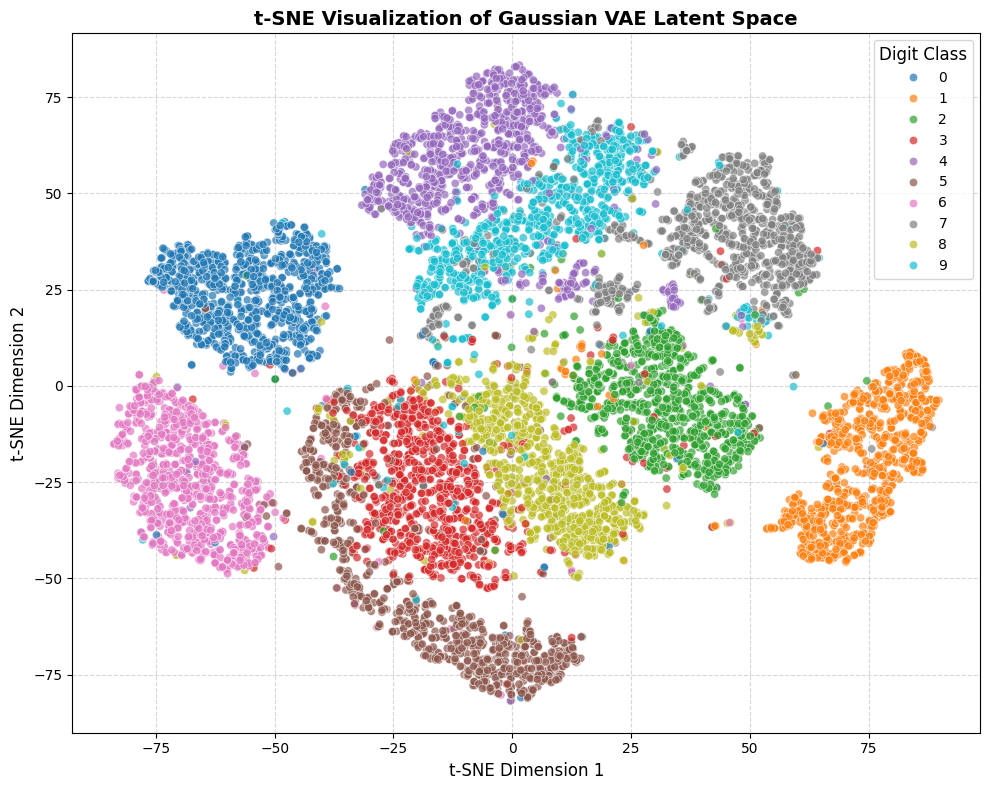

In [44]:
latent_space_tsne_visualization(gaussian_vae, gaussian_trainloader, title="t-SNE Visualization of Gaussian VAE Latent Space")

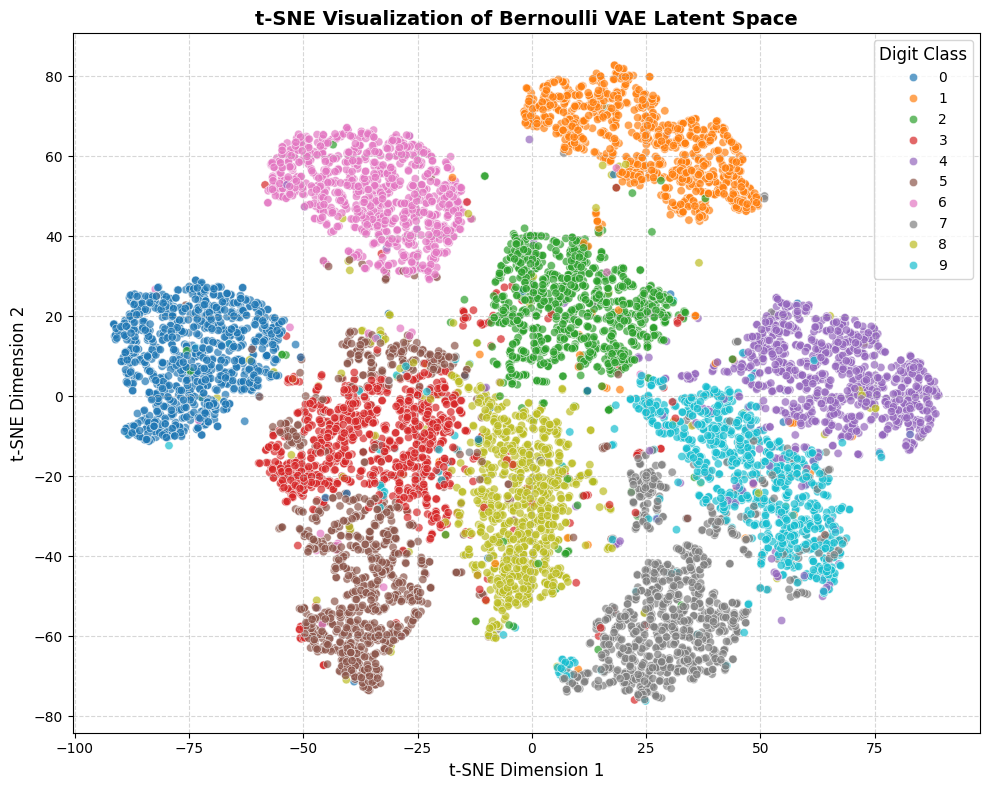

In [45]:
latent_space_tsne_visualization(bernoulli_vae, bernoulli_trainloader, title="t-SNE Visualization of Bernoulli VAE Latent Space")

### Data Interpolation in the latent space

Given the structure of the latent space learned by the VAE, we can perform interpolation between two points in the latent space. This allows us to generate a smooth transition between two different images.

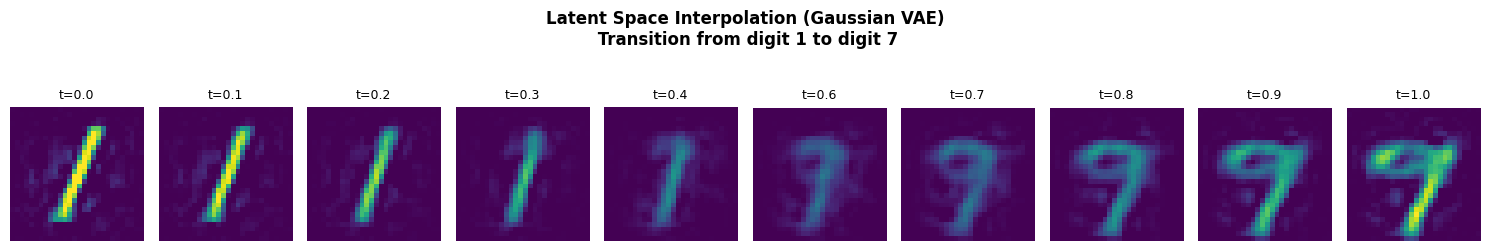

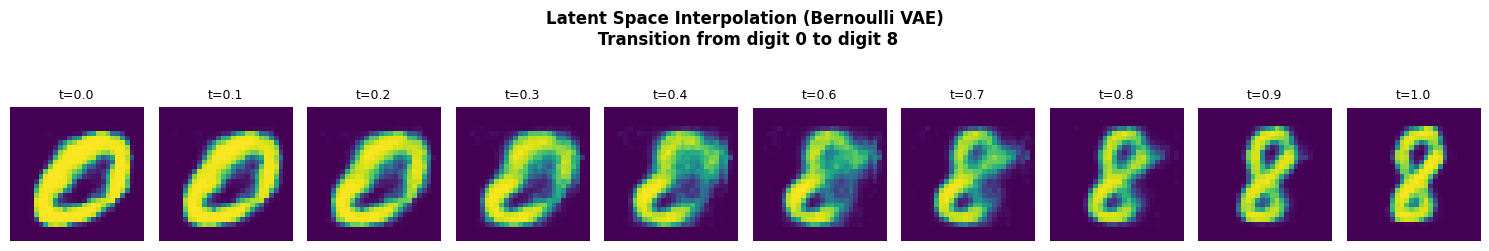

In [50]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def interpolate_latent_space(vae_model, data_loader, idx_A=0, idx_B=1, num_steps=10, title="Latent Space Interpolation"):
    """
    Generates a visual transition between two images in the latent space of a Gaussian VAE.

    Parameters:
    - vae_model: The trained VAE model.
    - data_loader: DataLoader for the dataset to sample images from.
    - idx_A: Index of the first image in the batch to interpolate from (default is 0).
    - idx_B: Index of the second image in the batch to interpolate to (default is 1).
    - num_steps: Number of interpolation steps between the two images (default is 10).
    - title: Title for the entire figure (default is "Latent Space Interpolation").
    """

    vae_model.eval()

    images, labels = next(iter(data_loader))

    img_A = images[idx_A].to(device)
    img_B = images[idx_B].to(device)

    label_A = labels[idx_A].item()
    label_B = labels[idx_B].item()

    with torch.no_grad():
        # Flatten the images if the encoder expects a vector of size 784
        x_A = img_A.view(1, -1)
        x_B = img_B.view(1, -1)

        mu_A, _ = vae_model.encoder(x_A)
        mu_B, _ = vae_model.encoder(x_B)

    # Define the interpolation steps
    steps = np.linspace(0, 1, num_steps)

    fig, axes = plt.subplots(1, num_steps, figsize=(15, 2.5))
    
    for i, t in enumerate(steps):
        # Linear interpolation formula: (1 - t) * A + t * B
        interpolated_vector = (1.0 - t) * mu_A + t * mu_B

        with torch.no_grad():
            # Pass the interpolated coordinate directly to the Decoder
            decoded_image = vae_model.decoder(interpolated_vector)

            # Reshape the output to 2D format (28x28 pixels) for visualization
            image_numpy = decoded_image.view(NEW_HEIGHT, NEW_WIDTH).cpu().numpy()

        # Plot the resulting image in its respective subplot
        axes[i].imshow(image_numpy, cmap=CMAP, vmin=0, vmax=1)
        axes[i].axis('off')
        axes[i].set_title(f"t={t:.1f}", fontsize=9)

    plt.suptitle(f"{title}\n Transition from digit {label_A} to digit {label_B}", fontsize=12, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

interpolate_latent_space(gaussian_vae, gaussian_trainloader, idx_A=0, idx_B=1, num_steps=10, title="Latent Space Interpolation (Gaussian VAE)")
interpolate_latent_space(bernoulli_vae, bernoulli_trainloader, idx_A=0, idx_B=1, num_steps=10, title="Latent Space Interpolation (Bernoulli VAE)")